# Merged Model Eval - 2026-06-11

Analyze CARC eval results exported from `eval_merged_*_to_*_11_06_2026_*` runs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
CSV_PATH = Path("eval_results.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("scripts/plotting/eval_merged_11_06_2026/eval_results.csv")
CSV_PATH = CSV_PATH.resolve()

SPLIT = "test"
METRIC = "roc_auc"
METRICS = ["accuracy", "f1", "roc_auc"]

SHOT_ORDER = [0, 3, 10]
DATASET_ORDER = [
    "covid19_twitter",
    "ukr_rus_twitter",
    "midterm",
    "covid_political",
    "election2020",
    "ukr_rus_suspended",
]
TASK_ORDER = ["nm", "lp", "pl"]
TASK_LABELS = {
    "nm": "Neighbor matching",
    "lp": "Temporal link prediction",
    "pl": "Classification",
}
MODEL_ORDER = ["merged_nm", "merged_lp"]
MODEL_LABELS = {
    "merged_nm": "Merged NM",
    "merged_lp": "Merged LP",
}

In [3]:
df = pd.read_csv(CSV_PATH)

required = {"model", "dataset", "task", "shots", "split", *METRICS}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

df["shots"] = df["shots"].astype(int)
for col in METRICS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

unexpected_models = sorted(set(df["model"]) - set(MODEL_ORDER))
unexpected_shots = sorted(set(df["shots"]) - set(SHOT_ORDER))
unexpected_splits = sorted(set(df["split"]) - {SPLIT})
if unexpected_models:
    raise ValueError(f"Unexpected model values: {unexpected_models}")
if unexpected_shots:
    raise ValueError(f"Unexpected shot values: {unexpected_shots}")
if unexpected_splits:
    raise ValueError(f"Unexpected split values: {unexpected_splits}")

df["dataset"] = pd.Categorical(df["dataset"], categories=DATASET_ORDER, ordered=True)
df["task"] = pd.Categorical(df["task"], categories=TASK_ORDER, ordered=True)
df["model"] = pd.Categorical(df["model"], categories=MODEL_ORDER, ordered=True)
df["model_label"] = df["model"].astype(str).map(MODEL_LABELS)
df["task_label"] = df["task"].astype(str).map(TASK_LABELS)
df = df.sort_values(["split", "dataset", "task", "model", "shots"])

print(f"reading {CSV_PATH}")
print(f"rows: {len(df)}")
display(df.head())

reading /Users/philipp/projects/gfm/prodigy/scripts/plotting/eval_merged_11_06_2026/eval_results.csv
rows: 90


,run_name,model,checkpoint,dataset,task,task_name,shots,timestamp,split,run_dir,metrics_path,accuracy,f1,roc_auc,model_label,task_label
48,eval_merged_nm_to_covid19_twitter_nm_0shot_11_...,merged_nm,merged_nm,covid19_twitter,nm,neighbor_matching,0,11_06_2026_19_55_11,test,/home1/eibl/gfm/prodigy/log/eval_merged_nm_to_...,/home1/eibl/gfm/prodigy/log/eval_merged_nm_to_...,0.335694,0.240232,0.500624,Merged NM,Neighbor matching
49,eval_merged_nm_to_covid19_twitter_nm_3shot_11_...,merged_nm,merged_nm,covid19_twitter,nm,neighbor_matching,3,11_06_2026_19_57_00,test,/home1/eibl/gfm/prodigy/log/eval_merged_nm_to_...,/home1/eibl/gfm/prodigy/log/eval_merged_nm_to_...,0.928333,0.928284,0.990387,Merged NM,Neighbor matching
50,eval_merged_nm_to_covid19_twitter_nm_10shot_11...,merged_nm,merged_nm,covid19_twitter,nm,neighbor_matching,10,11_06_2026_20_07_32,test,/home1/eibl/gfm/prodigy/log/eval_merged_nm_to_...,/home1/eibl/gfm/prodigy/log/eval_merged_nm_to_...,0.941306,0.941296,0.993081,Merged NM,Neighbor matching
3,eval_merged_lp_to_covid19_twitter_nm_0shot_11_...,merged_lp,merged_lp,covid19_twitter,nm,neighbor_matching,0,11_06_2026_19_58_24,test,/home1/eibl/gfm/prodigy/log/eval_merged_lp_to_...,/home1/eibl/gfm/prodigy/log/eval_merged_lp_to_...,0.331472,0.256269,0.507582,Merged LP,Neighbor matching
4,eval_merged_lp_to_covid19_twitter_nm_3shot_11_...,merged_lp,merged_lp,covid19_twitter,nm,neighbor_matching,3,11_06_2026_19_59_41,test,/home1/eibl/gfm/prodigy/log/eval_merged_lp_to_...,/home1/eibl/gfm/prodigy/log/eval_merged_lp_to_...,0.797056,0.797040,0.934731,Merged LP,Neighbor matching


In [4]:
coverage = (
    df.groupby(["model", "dataset", "task"], observed=True)
      .agg(shots=("shots", lambda x: sorted(set(x))), rows=("shots", "size"))
      .reset_index()
      .sort_values(["model", "dataset", "task"])
)

display(coverage)

wide_coverage = (
    df.groupby(["dataset", "task", "shots", "model"], observed=True)
      .size()
      .rename("rows")
      .reset_index()
      .pivot_table(
          index=["dataset", "task", "shots"],
          columns="model",
          values="rows",
          fill_value=0,
          observed=True,
      )
      .reset_index()
      .sort_values(["dataset", "task", "shots"])
)

display(wide_coverage)

,model,dataset,task,shots,rows
0,merged_nm,covid19_twitter,nm,"[0, 3, 10]",3
1,merged_nm,covid19_twitter,lp,"[0, 3, 10]",3
2,merged_nm,covid19_twitter,pl,"[0, 3, 10]",3
3,merged_nm,ukr_rus_twitter,nm,"[0, 3, 10]",3
4,merged_nm,ukr_rus_twitter,lp,"[0, 3, 10]",3
5,merged_nm,ukr_rus_twitter,pl,"[0, 3, 10]",3
6,merged_nm,midterm,nm,"[0, 3, 10]",3
7,merged_nm,midterm,lp,"[0, 3, 10]",3
8,merged_nm,midterm,pl,"[0, 3, 10]",3
9,merged_nm,covid_political,nm,"[0, 3, 10]",3


model,dataset,task,shots,merged_nm,merged_lp
0,covid19_twitter,nm,0,1.0,1.0
1,covid19_twitter,nm,3,1.0,1.0
2,covid19_twitter,nm,10,1.0,1.0
3,covid19_twitter,lp,0,1.0,1.0
4,covid19_twitter,lp,3,1.0,1.0
5,covid19_twitter,lp,10,1.0,1.0
6,covid19_twitter,pl,0,1.0,1.0
7,covid19_twitter,pl,3,1.0,1.0
8,covid19_twitter,pl,10,1.0,1.0
9,ukr_rus_twitter,nm,0,1.0,1.0


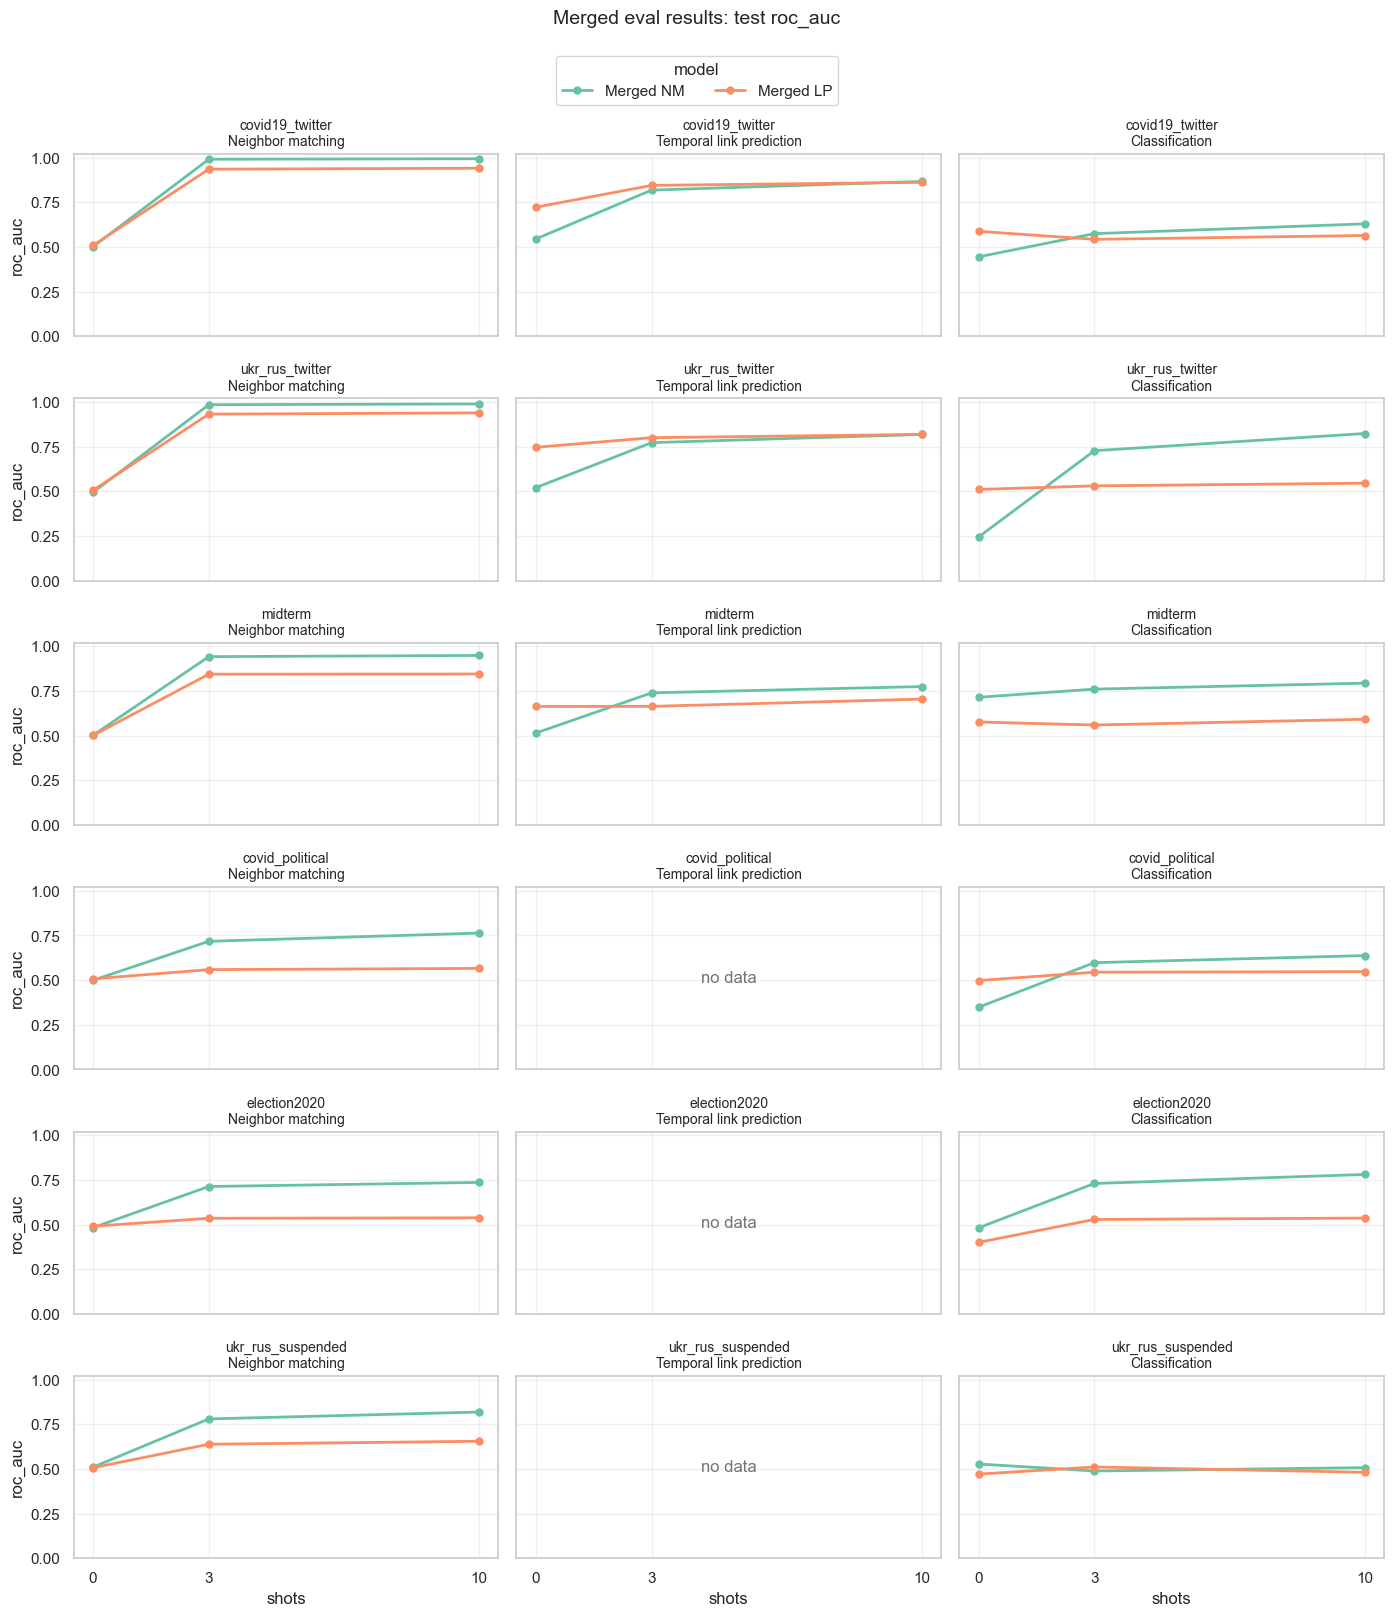

In [5]:
def plot_metric_grid(data, *, split=SPLIT, metric=METRIC, datasets=DATASET_ORDER, tasks=TASK_ORDER):
    subset = data[(data["split"] == split) & data[metric].notna()].copy()
    if subset.empty:
        raise ValueError(f"No rows for split={split!r}, metric={metric!r}")

    palette = dict(zip(MODEL_ORDER, sns.color_palette("Set2", n_colors=len(MODEL_ORDER))))
    fig, axes = plt.subplots(
        nrows=len(datasets),
        ncols=len(tasks),
        figsize=(4.7 * len(tasks), 2.6 * len(datasets)),
        sharex=True,
        sharey=True,
    )

    if len(datasets) == 1 and len(tasks) == 1:
        axes = [[axes]]
    elif len(datasets) == 1:
        axes = [axes]
    elif len(tasks) == 1:
        axes = [[ax] for ax in axes]

    for row_idx, dataset in enumerate(datasets):
        for col_idx, task in enumerate(tasks):
            ax = axes[row_idx][col_idx]
            panel = subset[(subset["dataset"].astype(str) == dataset) & (subset["task"].astype(str) == task)]
            ax.set_title(f"{dataset}\n{TASK_LABELS.get(task, task)}", fontsize=10)

            if panel.empty:
                ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center", va="center", color="0.45")
            else:
                for model in MODEL_ORDER:
                    line = panel[panel["model"].astype(str) == model].sort_values("shots")
                    if line.empty:
                        continue
                    ax.plot(
                        line["shots"],
                        line[metric],
                        marker="o",
                        linewidth=2,
                        markersize=5,
                        color=palette[model],
                        label=MODEL_LABELS.get(model, model),
                    )

            ax.set_ylim(0, 1.02)
            ax.set_xticks(SHOT_ORDER)
            ax.grid(True, alpha=0.3)
            if row_idx == len(datasets) - 1:
                ax.set_xlabel("shots")
            if col_idx == 0:
                ax.set_ylabel(metric)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title="model", loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.01))
    fig.suptitle(f"Merged eval results: {split} {metric}", y=1.035, fontsize=14)
    fig.tight_layout()
    return fig

plot_metric_grid(df, metric=METRIC)
plt.show()

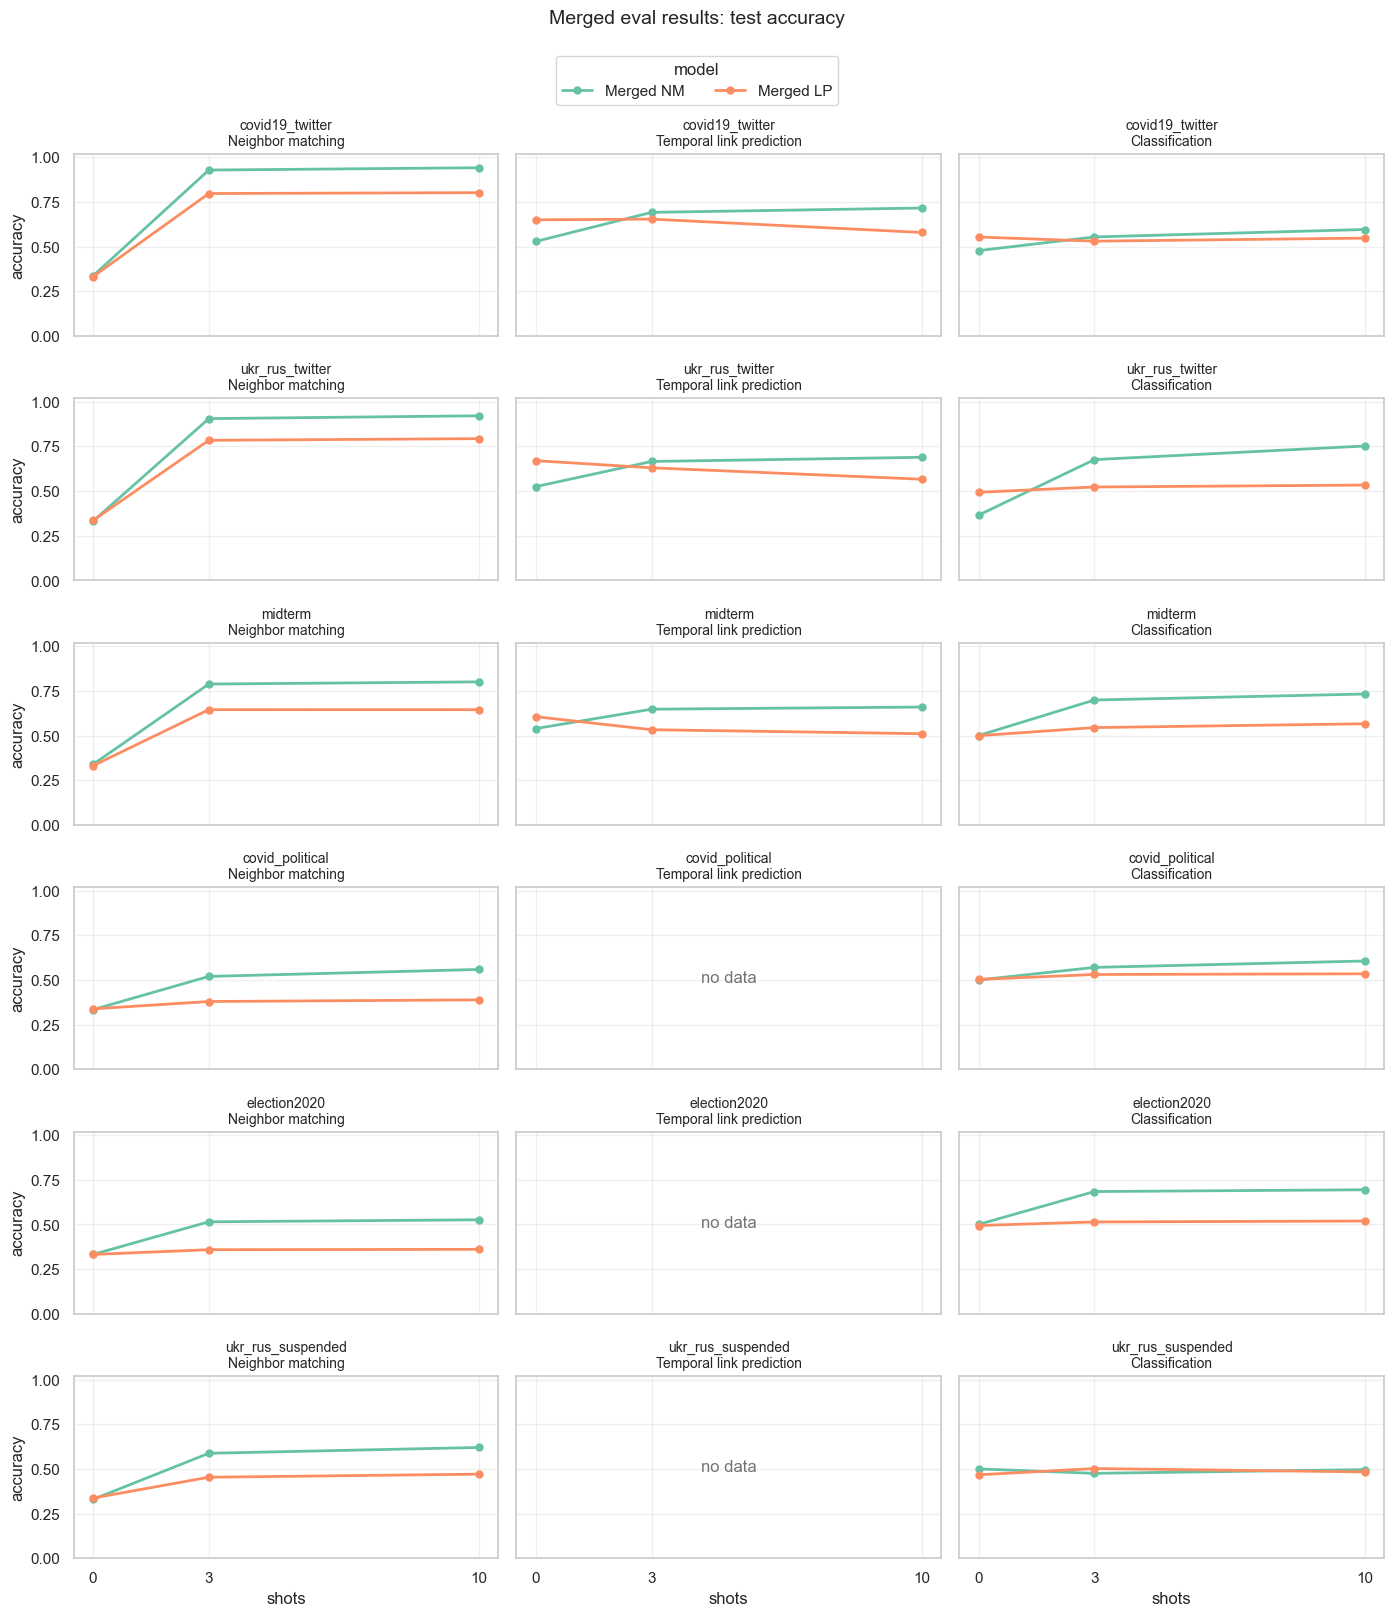

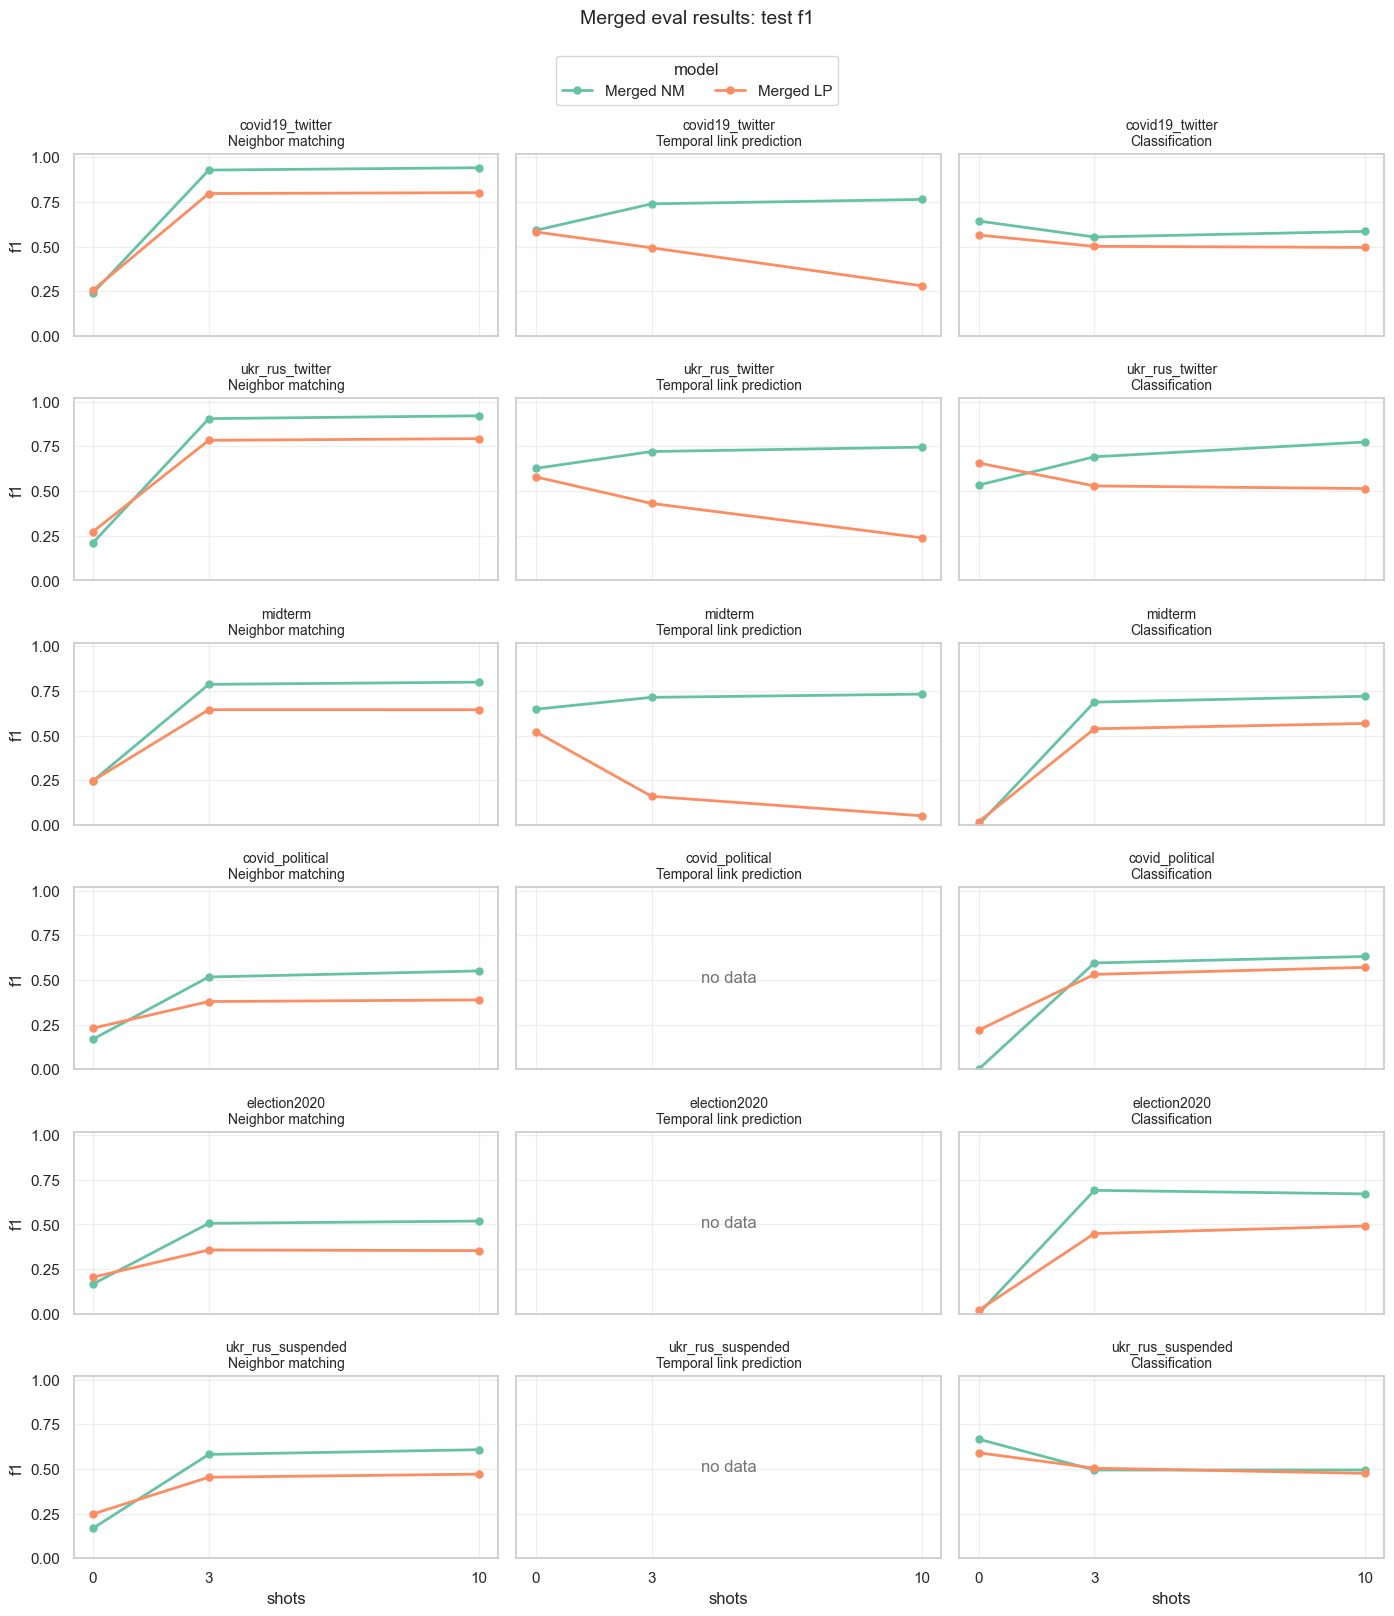

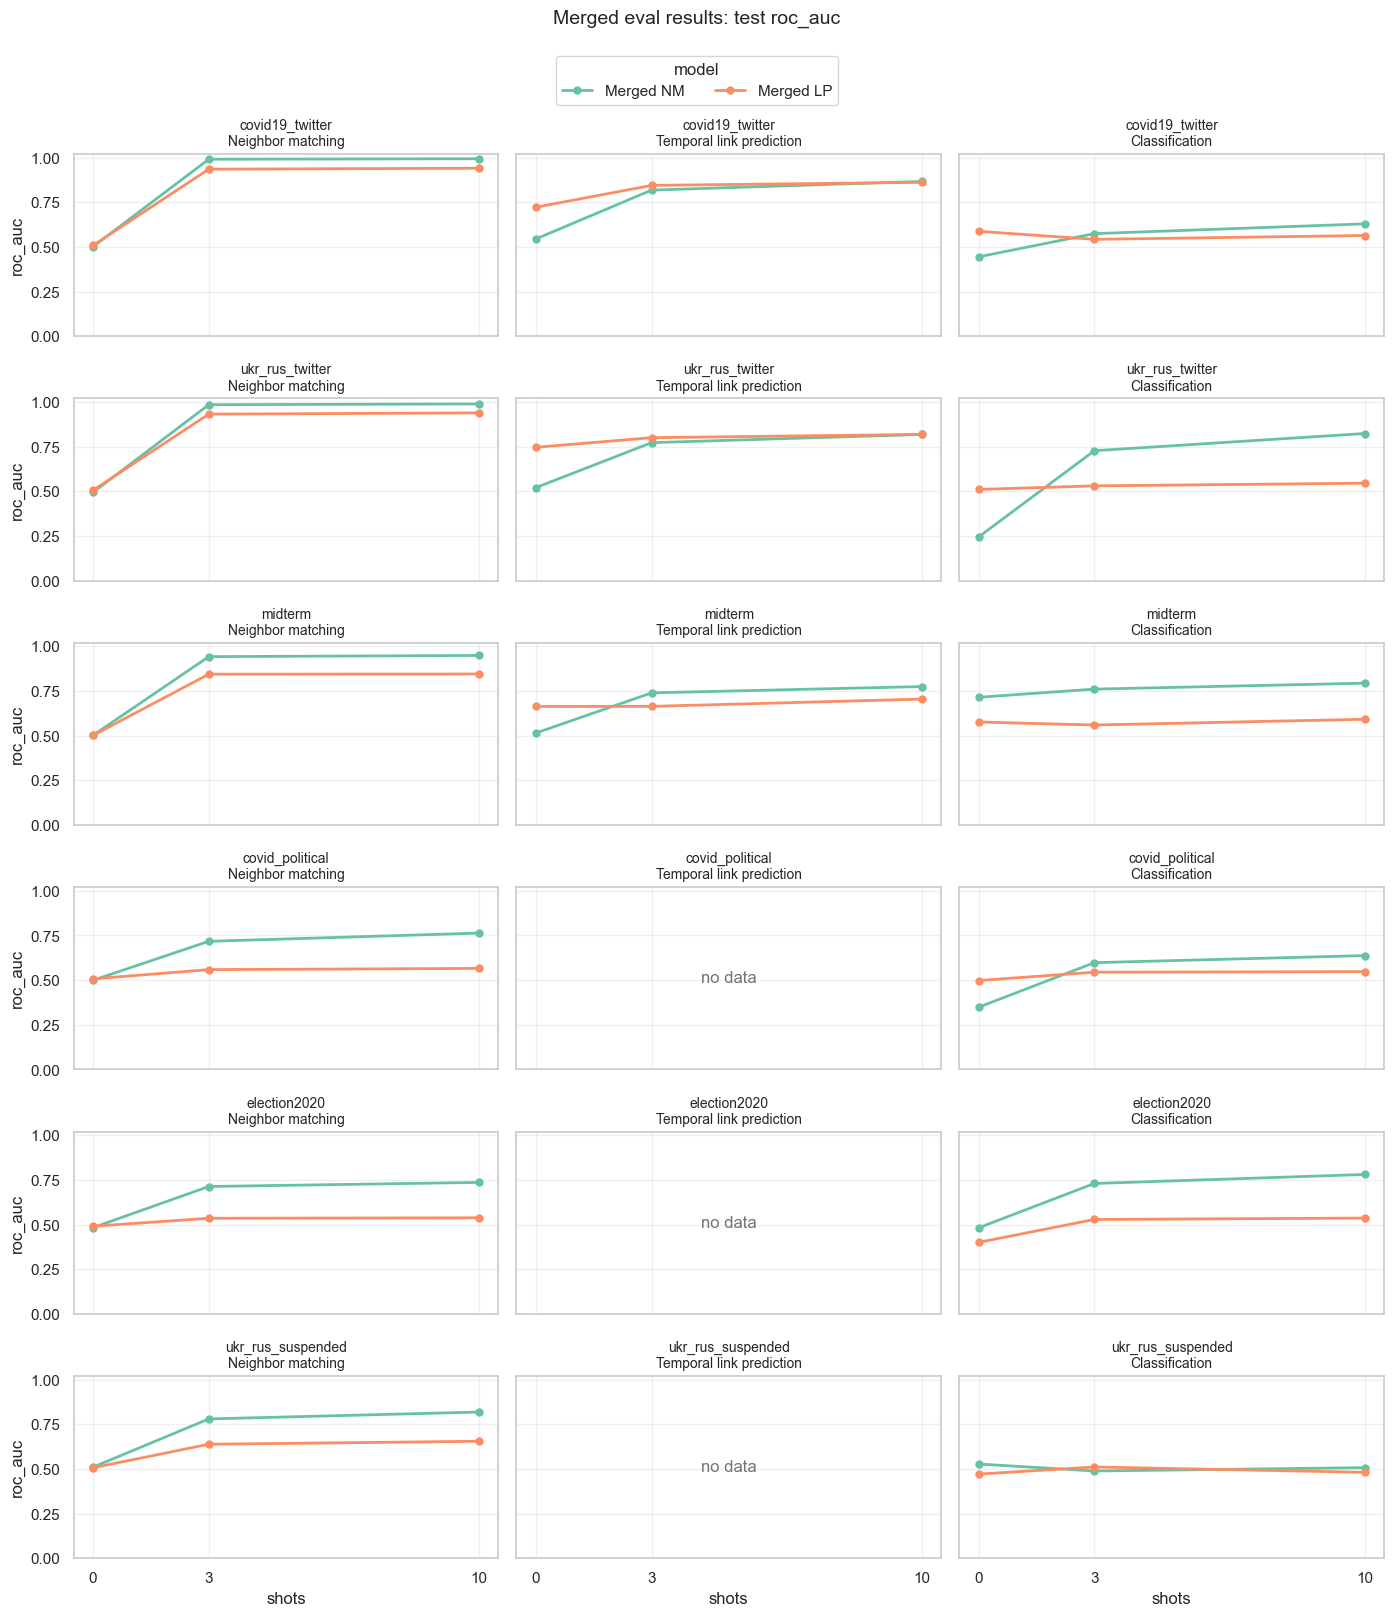

In [6]:
for metric in METRICS:
    plot_metric_grid(df, metric=metric)
    plt.show()

In [7]:
delta = (
    df.pivot_table(
        index=["dataset", "task", "shots"],
        columns="model",
        values=METRICS,
        observed=True,
    )
    .reset_index()
)

for metric in METRICS:
    delta[(metric, "merged_nm_minus_lp")] = delta[(metric, "merged_nm")] - delta[(metric, "merged_lp")]

delta.columns = ["_".join([str(part) for part in col if str(part)]) if isinstance(col, tuple) else col for col in delta.columns]
display(delta.sort_values(["dataset", "task", "shots"]))

,dataset,task,shots,accuracy_merged_nm,accuracy_merged_lp,f1_merged_nm,f1_merged_lp,roc_auc_merged_nm,roc_auc_merged_lp,accuracy_merged_nm_minus_lp,f1_merged_nm_minus_lp,roc_auc_merged_nm_minus_lp
0,covid19_twitter,nm,0,0.335694,0.331472,0.240232,0.256269,0.500624,0.507582,0.004222,-0.016037,-0.006958
1,covid19_twitter,nm,3,0.928333,0.797056,0.928284,0.797040,0.990387,0.934731,0.131278,0.131244,0.055656
2,covid19_twitter,nm,10,0.941306,0.801833,0.941296,0.801815,0.993081,0.939998,0.139472,0.139481,0.053083
3,covid19_twitter,lp,0,0.528667,0.649875,0.591093,0.582044,0.543910,0.721674,-0.121208,0.009049,-0.177765
4,covid19_twitter,lp,3,0.691583,0.653792,0.739201,0.493385,0.817567,0.844017,0.037792,0.245816,-0.026450
5,covid19_twitter,lp,10,0.715875,0.579083,0.764008,0.280382,0.866069,0.861202,0.136792,0.483626,0.004867
6,covid19_twitter,pl,0,0.477583,0.553583,0.643260,0.564719,0.443981,0.587037,-0.076000,0.078540,-0.143055
7,covid19_twitter,pl,3,0.554083,0.530417,0.553860,0.501460,0.573900,0.542010,0.023667,0.052400,0.031890
8,covid19_twitter,pl,10,0.595667,0.547458,0.585086,0.495424,0.628638,0.563447,0.048208,0.089662,0.065192
9,ukr_rus_twitter,nm,0,0.330861,0.335444,0.210546,0.273097,0.493456,0.505293,-0.004583,-0.062551,-0.011837


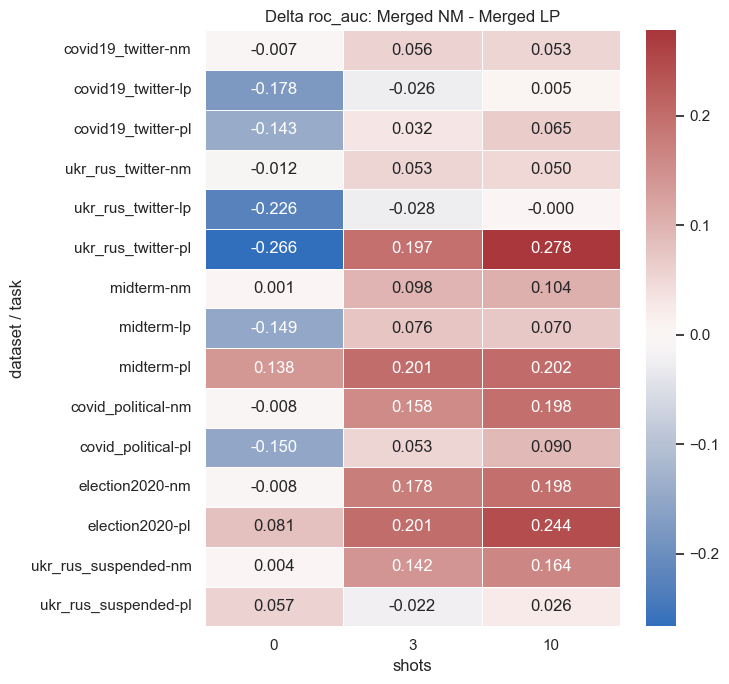

In [8]:
delta_metric = f"{METRIC}_merged_nm_minus_lp"
heat = delta.pivot_table(
    index=["dataset", "task"],
    columns="shots",
    values=delta_metric,
    observed=True,
)

fig, ax = plt.subplots(figsize=(7.5, 7.0))
sns.heatmap(heat, annot=True, fmt=".3f", center=0, cmap="vlag", linewidths=0.5, ax=ax)
ax.set_title(f"Delta {METRIC}: Merged NM - Merged LP")
ax.set_xlabel("shots")
ax.set_ylabel("dataset / task")
fig.tight_layout()
plt.show()

In [9]:
best_rows = []
for metric in METRICS:
    idx = df.groupby(["model", "dataset", "task"], observed=True)[metric].idxmax()
    best = df.loc[idx, ["model_label", "dataset", "task", "shots", metric]].copy()
    best["metric"] = metric
    best = best.rename(columns={metric: "value"})
    best_rows.append(best)

best_table = pd.concat(best_rows, ignore_index=True)
display(best_table[["metric", "model_label", "dataset", "task", "shots", "value"]].sort_values(["metric", "dataset", "task", "model_label"]))

,metric,model_label,dataset,task,shots,value
15,accuracy,Merged LP,covid19_twitter,nm,10,0.801833
0,accuracy,Merged NM,covid19_twitter,nm,10,0.941306
16,accuracy,Merged LP,covid19_twitter,lp,3,0.653792
1,accuracy,Merged NM,covid19_twitter,lp,10,0.715875
17,accuracy,Merged LP,covid19_twitter,pl,0,0.553583
...,...,...,...,...,...,...
72,roc_auc,Merged NM,election2020,pl,10,0.780116
88,roc_auc,Merged LP,ukr_rus_suspended,nm,10,0.654725
73,roc_auc,Merged NM,ukr_rus_suspended,nm,10,0.818314
89,roc_auc,Merged LP,ukr_rus_suspended,pl,3,0.510848


In [10]:
# Optional: save the main figure locally next to the CSV.
FIGURE_DIR = CSV_PATH.parent / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

for metric in METRICS:
    fig = plot_metric_grid(df, metric=metric)
    fig.savefig(FIGURE_DIR / f"eval_merged_11_06_2026_{metric}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

print(f"wrote figures to {FIGURE_DIR}")

wrote figures to /Users/philipp/projects/gfm/prodigy/scripts/plotting/eval_merged_11_06_2026/figures


In [21]:
df[df.shots.eq(3)][['model', 'dataset', 'task', 'roc_auc']].to_csv()

',model,dataset,task,roc_auc\n49,merged_nm,covid19_twitter,nm,0.990387402199074\n4,merged_lp,covid19_twitter,nm,0.9347313674768518\n46,merged_nm,covid19_twitter,lp,0.8175671527777777\n1,merged_lp,covid19_twitter,lp,0.8440172083333333\n52,merged_nm,covid19_twitter,pl,0.5738999166666666\n7,merged_lp,covid19_twitter,pl,0.5420101284722223\n85,merged_nm,ukr_rus_twitter,nm,0.984510342013889\n40,merged_lp,ukr_rus_twitter,nm,0.9316915306712962\n82,merged_nm,ukr_rus_twitter,lp,0.7720798645833333\n37,merged_lp,ukr_rus_twitter,lp,0.7998632222222223\n88,merged_nm,ukr_rus_twitter,pl,0.72688384375\n43,merged_lp,ukr_rus_twitter,pl,0.5301714895833334\n70,merged_nm,midterm,nm,0.9423645613425924\n25,merged_lp,midterm,nm,0.8440921903935186\n67,merged_nm,midterm,lp,0.7395750138888889\n22,merged_lp,midterm,lp,0.6640420694444444\n73,merged_nm,midterm,pl,0.7605627430555555\n28,merged_lp,midterm,pl,0.5595543125\n55,merged_nm,covid_political,nm,0.7169772777777776\n10,merged_lp,covid_political,nm,0.558677826388